# Length of Stay Category Prediction Model

**Purpose:** Build a machine learning classification model to predict treatment duration category (1-7 days, 8-30 days, 31-90 days, etc.) at admission for resource planning and personalized treatment.

**Dataset:** TEDS-D 2023 Analysis-Ready Dataset  
**Target Variable:** `length_of_stay` (categorical: 6 categories)  
**Training Records:** ~522,531 patients with known length of stay

**Categories:**
- 1-7 days (Short stay)
- 8-30 days (Brief stay)
- 31-90 days (Medium stay)
- 91-180 days (Extended stay)
- 181-365 days (Long stay)
- More than 1 year (Very long stay)

## Step 1: Load Data and Initial Exploration

Load the ML-ready dataset and examine the distribution of length of stay among patients with non-missing data.

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import re
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("1_datasets/processed/teds_d_analysis_ready.csv")

df_model = df[df["length_of_stay"].notna()].copy()

print(f"Total records in dataset:   {len(df):,}")
print(f"Records with LOS data:      {len(df_model):,}")
print(f"Percentage with LOS data:   {len(df_model) / len(df) * 100:.2f}%")
print(df_model["length_of_stay"].value_counts().sort_index())


Total records in dataset:   1,474,025
Records with LOS data:      522,531
Percentage with LOS data:   35.45%
length_of_stay
1-7 days            297906
181-365 days         44908
31-90 days           47224
8-30 days            56109
91-180 days          43951
More than 1 year     32433
Name: count, dtype: int64


## Step 2: Visualize Length of Stay Distribution

Examine the distribution of length of stay categories to understand class balance.

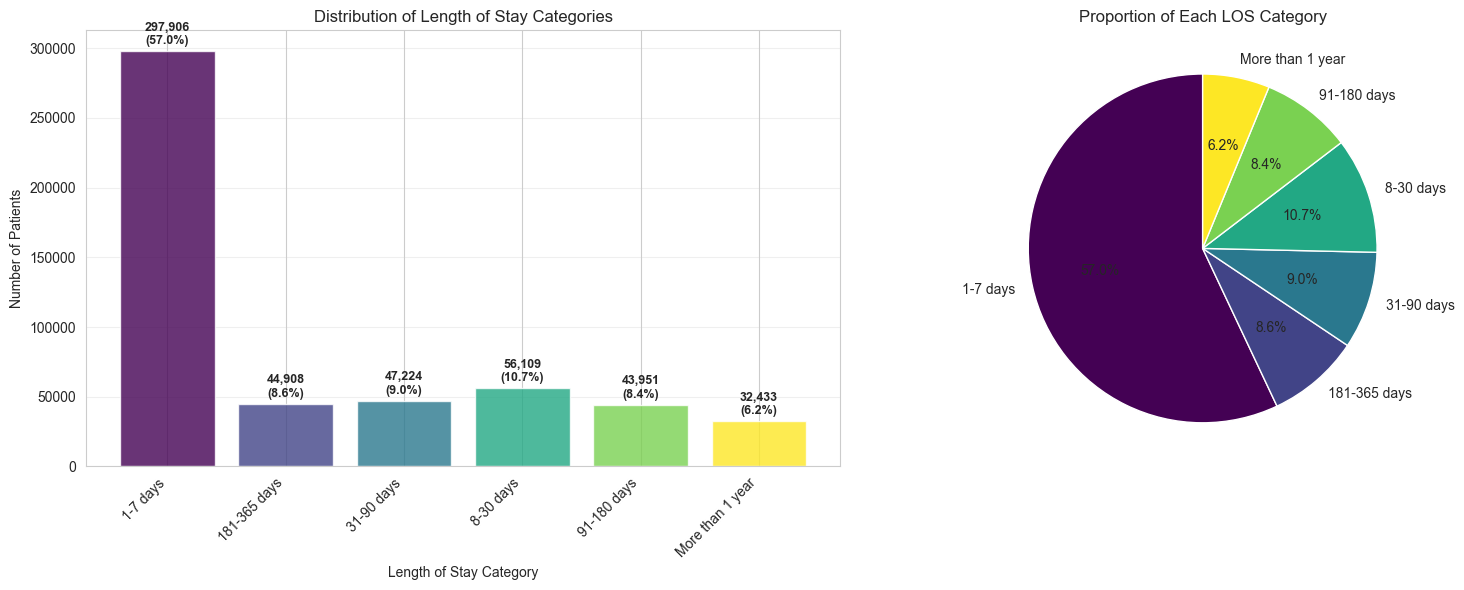

Most common class: 1-7 days (57.0%)
Least common class: More than 1 year (6.2%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

los_counts = df_model["length_of_stay"].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, len(los_counts)))

axes[0].bar(range(len(los_counts)), los_counts.values, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(los_counts)))
axes[0].set_xticklabels(los_counts.index, rotation=45, ha="right")
axes[0].set_xlabel("Length of Stay Category")
axes[0].set_ylabel("Number of Patients")
axes[0].set_title("Distribution of Length of Stay Categories")
axes[0].grid(True, alpha=0.3, axis="y")

for i, (cat, count) in enumerate(los_counts.items()):
    axes[0].text(
        i,
        count + 5000,
        f"{count:,}\n({count / len(df_model) * 100:.1f}%)",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

axes[1].pie(
    los_counts.values,
    labels=los_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
)
axes[1].set_title("Proportion of Each LOS Category")

plt.tight_layout()
plt.show()

print(
    f"Most common class: {los_counts.index[0]} ({los_counts.values[0] / len(df_model) * 100:.1f}%)"
)
print(
    f"Least common class: {los_counts.index[-1]} ({los_counts.values[-1] / len(df_model) * 100:.1f}%)"
)


## Step 3: Define Features for Prediction

Select features available at admission that could predict length of stay category. These include demographics, substance use patterns, treatment history, and clinical indicators.

In [ ]:
features = [
    # Demographics
    "age_group",
    "sex",
    "race",
    "ethnicity",
    "marital_status",
    "education_level",
    "employment_admit",
    "living_arrangement_admit",
    "income_source",
    "veteran_status",
    # Substance use
    "primary_substance_admit",
    "secondary_substance_admit",
    "tertiary_substance_admit",
    "route_primary",
    "frequency_primary_admit",
    "age_first_use_primary",
    "years_using",
    "number_of_substances_admit",
    # Treatment factors
    "referral_source",
    "prior_treatments",
    "wait_time_days",
    "medication_assisted_therapy",
    "self_help_attendance_admit",
    "substance_category",
    # Clinical
    "dsm_diagnosis",
    "injection_drug_use",
    "pregnant",
    "health_insurance",
    "payment_source",
    "arrests_admit",
    "has_cooccurring_mental_health",
    # Engineered features
    "is_polysubstance",
    "is_opioid_primary",
    "is_stimulant_primary",
    "is_alcohol_primary",
    "is_cannabis_primary",
    "is_injection_user",
    "is_criminal_justice_referral",
    "is_chronic_treatment",
    "is_first_treatment",
    "has_long_wait",
    "is_adolescent",
    "is_older_adult",
    "is_pregnant",
    "has_no_income",
    "has_mental_health_disorder",
]
# Define the mapping
los_mapping = {
    "1-7 days": "Short (1-7 days)",
    "8-30 days": "Medium (8-90 days)",
    "31-90 days": "Medium (8-90 days)",
    "91-180 days": "Long (90+ days)",
    "181-365 days": "Long (90+ days)",
    "More than 1 year": "Long (90+ days)",
}

# Apply mapping to create a new target variable
df_model["length_of_stay_collapsed"] = df_model["length_of_stay"].map(los_mapping)

# Check the new balance
print("New Target Distribution:")
print(df_model["length_of_stay_collapsed"].value_counts(normalize=True))


New Target Distribution:
length_of_stay_collapsed
Short (1-7 days)      0.570121
Long (90+ days)       0.232124
Medium (8-90 days)    0.197755
Name: proportion, dtype: float64


## Step 4: Prepare Data for Modeling

Handle missing values, encode categorical variables, and split into training and test sets.

In [ ]:
X = df_model[features].copy()
y = df_model['length_of_stay'].copy()

print(f"Initial feature count: {X.shape[1]}")

missing_counts = X.isnull().sum()
missing_features = missing_counts[missing_counts > 0]

if len(missing_features) > 0:
    print("\nFeatures with missing values:")
    for feat, count in missing_features.items():
        print(f"  {feat:30} {count:>8,} ({count/len(X)*100:>5.2f}%)")
    
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            if X[col].dtype in ['object', 'category']:
                X[col] = X[col].fillna('Unknown')
            else:
                X[col] = X[col].fillna(X[col].median())

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nFeatures after encoding: {X_encoded.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(y_train.value_counts(normalize=True).sort_index())

# Initialize the undersampler
# 'sampling_strategy'='auto' balances all classes to match the minority class size
rus = RandomUnderSampler(random_state=42)

# Resample ONLY the training data
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print(f"\nOriginal Training Shape: {X_train.shape}")
print(f"Resampled Training Shape: {X_train_resampled.shape}")
print("\nBalanced Class Distribution in Training:")
print(y_train_resampled.value_counts(normalize=True))

Initial feature count: 46

Features with missing values:
  sex                                 229 ( 0.04%)
  race                             29,653 ( 5.67%)
  ethnicity                        29,543 ( 5.65%)
  marital_status                  131,162 (25.10%)
  education_level                 117,156 (22.42%)
  employment_admit                 67,817 (12.98%)
  living_arrangement_admit        101,585 (19.44%)
  income_source                   359,845 (68.87%)
  veteran_status                   72,744 (13.92%)
  primary_substance_admit          83,703 (16.02%)
  secondary_substance_admit       282,001 (53.97%)
  tertiary_substance_admit        423,719 (81.09%)
  route_primary                    88,761 (16.99%)
  frequency_primary_admit          90,220 (17.27%)
  age_first_use_primary            92,285 (17.66%)
  years_using                      92,285 (17.66%)
  referral_source                  65,937 (12.62%)
  prior_treatments                 59,293 (11.35%)
  wait_time_days         

In [ ]:
# Define Features
X = df_model[features].copy()

# Define Target
y = df_model["length_of_stay_collapsed"].copy() 

# Handle Missing Values & Encoding
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print("Target Class Distribution in Training:")
print(y_train_resampled.value_counts(normalize=True))


Target Class Distribution in Training (Should be 33% each):
length_of_stay_collapsed
Long (90+ days)       0.333333
Medium (8-90 days)    0.333333
Short (1-7 days)      0.333333
Name: proportion, dtype: float64


## Step 5: Train Random Forest Classifier

Train a Random Forest classifier to predict length of stay category.

In [ ]:
# Define the parameter search space
param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [2, 5, 10],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True],
}

# Initialize the Random Forest
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# Set up the Randomized Search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3, 
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro",
)

# Fit on the RESAMPLED training data
print("Starting Hyperparameter Tuning (this may take 2-3 minutes)...")
rf_random.fit(X_train_resampled, y_train_resampled)

# Get the best model
best_rf_model = rf_random.best_estimator_

print(f"\nBest Parameters Found: {rf_random.best_params_}")
print(f"Best Cross-Validation Score: {rf_random.best_score_:.4f}")

# Generate predictions on the Test set
y_pred_rf = best_rf_model.predict(X_test)

# Basic Evaluation
accuracy = accuracy_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf, average="macro")

print(f"\nTest Set Accuracy: {accuracy:.4f}")
print(f"Test Set Macro F1: {f1:.4f}")

# Update the main model variable for later steps
rf_model = best_rf_model

Starting Hyperparameter Tuning (this may take 2-3 minutes)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters Found: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}
Best Cross-Validation Score: 0.6113

Test Set Accuracy: 0.6987
Test Set Macro F1: 0.6192


## Step 6: Train Gradient Boosting Classifier

Train a Gradient Boosting classifier for comparison.

In [ ]:
def clean_cols_lgbm(df):
    new_cols = []
    for c in df.columns:
        # Replace forbidden characters with an underscore
        # This includes [ and ] which can sometimes bypass the \W regex in certain contexts
        c = re.sub(r"[\[\]\<\>:,]", "_", c)
        # Ensure only word characters and underscores remain, and numbers aren't leading
        c = re.sub(r"\W|^(?=\d)", "_", c)
        new_cols.append(c)
    df.columns = new_cols
    return df


# This ensures consistency for training and validation splits
X_train_resampled = clean_cols_lgbm(X_train_resampled.copy())
X_test = clean_cols_lgbm(X_test.copy())  

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.1, random_state=42
)

gb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

gb_model.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(50, verbose=False)],
    categorical_feature="auto",
)

# Use the best iteration model
best_iteration = gb_model.best_iteration_
gb_model.set_params(n_estimators=best_iteration)
gb_model.fit(X_train_resampled, y_train_resampled)

y_pred_gb = gb_model.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average="macro")

print(f"\nLightGBM Final Iteration: {best_iteration}")
print(f"LightGBM Accuracy: {accuracy_gb:.4f} ({accuracy_gb * 100:.2f}%)")
print(f"LightGBM Macro F1 Score: {f1_gb:.4f}")


Starting LightGBM Training...

LightGBM Final Iteration: 300
LightGBM Accuracy: 0.6909 (69.09%)
LightGBM Macro F1 Score: 0.5991


## Step 7: Compare Models and Select Best

Compare performance metrics and select the best model.

            Model  Accuracy  F1 Score
    Random Forest  0.698690  0.619218
Gradient Boosting  0.690901  0.599057

Best Model: Random Forest
  Accuracy: 0.6987 (69.87%)
  F1 Score: 0.6192


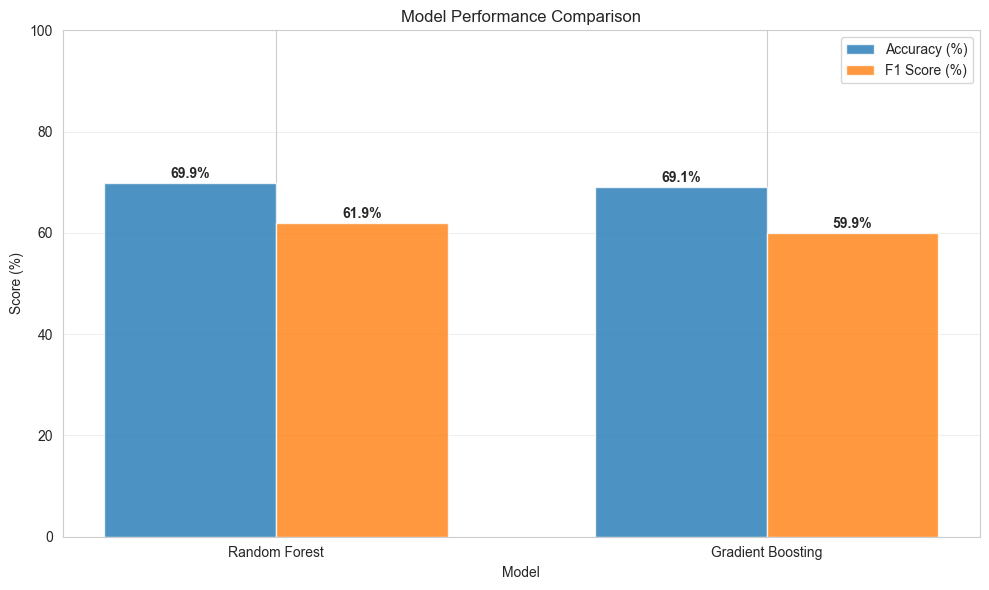

In [137]:
comparison = pd.DataFrame(
    {
        "Model": ["Random Forest", "Gradient Boosting"],
        "Accuracy": [accuracy, accuracy_gb],
        "F1 Score": [f1, f1_gb],
    }
)

print(comparison.to_string(index=False))

best_model = rf_model if f1 > f1_gb else gb_model
best_name = "Random Forest" if f1 > f1_gb else "Gradient Boosting"
y_pred_best = y_pred_rf if f1 > f1_gb else y_pred_gb
y_pred_best_proba = y_pred_rf if f1 > f1_gb else y_pred_gb
best_accuracy = accuracy if f1 > f1_gb else accuracy_gb
best_f1 = f1 if f1 > f1_gb else f1_gb

print(f"\nBest Model: {best_name}")
print(f"  Accuracy: {best_accuracy:.4f} ({best_accuracy * 100:.2f}%)")
print(f"  F1 Score: {best_f1:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(comparison))
width = 0.35

ax.bar(
    x_pos - width / 2,
    comparison["Accuracy"] * 100,
    width,
    label="Accuracy (%)",
    alpha=0.8,
)
ax.bar(
    x_pos + width / 2,
    comparison["F1 Score"] * 100,
    width,
    label="F1 Score (%)",
    alpha=0.8,
)

ax.set_xlabel("Model")
ax.set_ylabel("Score (%)")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison["Model"])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 100)

for i, (acc, f1) in enumerate(
    zip(comparison["Accuracy"] * 100, comparison["F1 Score"] * 100)
):
    ax.text(
        i - width / 2,
        acc + 1,
        f"{acc:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
    ax.text(
        i + width / 2, f1 + 1, f"{f1:.1f}%", ha="center", fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Step 8: Feature Importance Analysis

Identify which features are most important for predicting length of stay category.

                                    feature  importance
                              dsm_diagnosis    0.078893
                    wait_time_days_Same_day    0.054769
                                years_using    0.053742
            medication_assisted_therapy_Yes    0.044337
   self_help_attendance_admit_No_attendance    0.032111
                              has_no_income    0.031094
                 number_of_substances_admit    0.028846
                         is_alcohol_primary    0.021759
  frequency_primary_admit_No_use_past_month    0.016943
               marital_status_Never_married    0.016937
          living_arrangement_admit_Homeless    0.015795
            injection_drug_use_Not_reported    0.015653
living_arrangement_admit_Independent_living    0.015444
          has_cooccurring_mental_health_Yes    0.015124
               education_level_Grade_12_GED    0.014961
                 prior_treatments_One_prior    0.014682
                         is_first_treatment    0

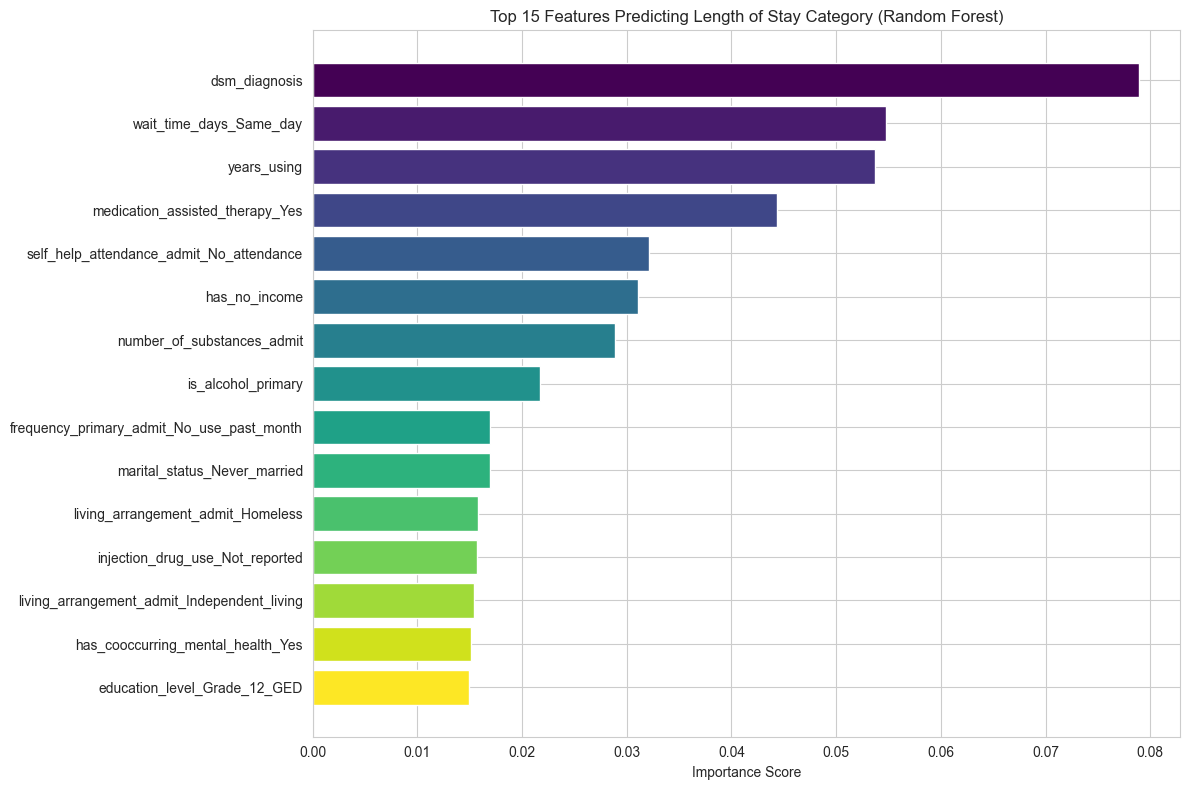

In [136]:
feature_importance = pd.DataFrame(
    {
        "feature": X_train_resampled.columns,
        "importance": best_rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

print(feature_importance.head(20).to_string(index=False))

plt.figure(figsize=(12, 8))
top_15 = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_15)))

plt.barh(range(len(top_15)), top_15["importance"], color=colors)
plt.yticks(range(len(top_15)), top_15["feature"])
plt.xlabel("Importance Score")
plt.title(f"Top 15 Features Predicting Length of Stay Category ({best_name})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Step 9: Confusion Matrix Analysis

Visualize the confusion matrix to see where the model makes correct and incorrect predictions.

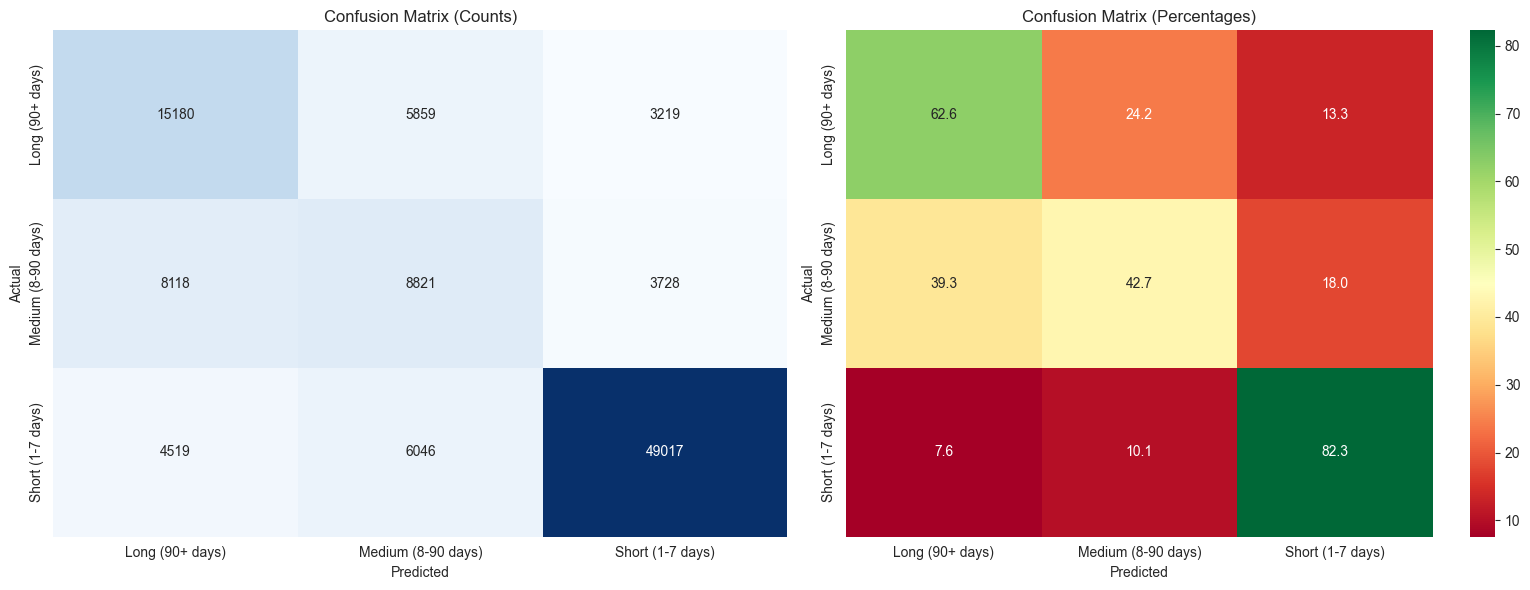

In [ ]:
# Get the unique categories from the actual test data
categories = sorted(y_test.unique())

# Generate matrix
cm = confusion_matrix(y_test, y_pred_best, labels=categories)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=categories,
    yticklabels=categories,
    ax=ax1,
)
ax1.set_title("Confusion Matrix (Counts)")
ax1.set_ylabel("Actual")
ax1.set_xlabel("Predicted")

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    cbar=True,
    xticklabels=categories,
    yticklabels=categories,
    ax=ax2,
)
ax2.set_title("Confusion Matrix (Percentages)")
ax2.set_ylabel("Actual")
ax2.set_xlabel("Predicted")

plt.tight_layout()
plt.show()


## Step 10: Detailed Classification Report

Generate a comprehensive classification report with precision, recall, and F1 scores for each category.

Classes found: ['Long (90+ days)', 'Medium (8-90 days)', 'Short (1-7 days)']

Classification Report:
                    precision    recall  f1-score   support

   Long (90+ days)       0.55      0.63      0.58     24258
Medium (8-90 days)       0.43      0.43      0.43     20667
  Short (1-7 days)       0.88      0.82      0.85     59582

          accuracy                           0.70    104507
         macro avg       0.62      0.63      0.62    104507
      weighted avg       0.71      0.70      0.70    104507



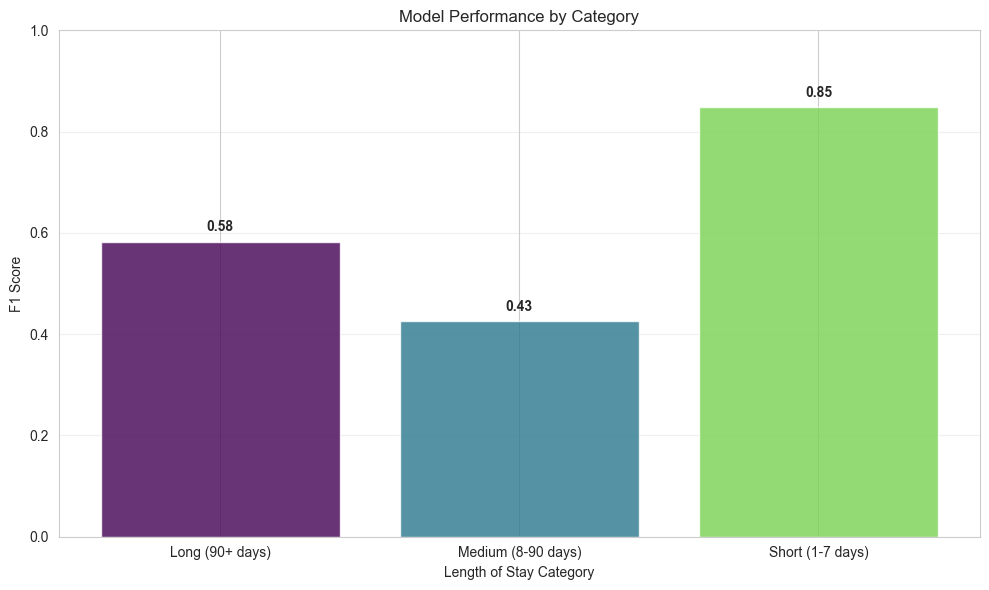

In [ ]:
# Generate fresh predictions using the successfully trained model
y_pred_best = best_rf_model.predict(X_test)

# Re-run the robust classification report code
unique_labels = sorted(list(set(y_test.unique()) | set(y_pred_best)))

print(f"Classes found: {unique_labels}")

# Print the report using the detected labels
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=unique_labels))

# Generate the F1 Score Chart
report_dict = classification_report(
    y_test, y_pred_best, target_names=unique_labels, output_dict=True
)

# Filter to just the classes (ignore accuracy/macro avg)
class_metrics = {k: v for k, v in report_dict.items() if k in unique_labels}
f1_scores = [class_metrics[cat]["f1-score"] for cat in unique_labels]

# Plot
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, len(unique_labels)))
plt.bar(unique_labels, f1_scores, color=colors, alpha=0.8)
plt.xlabel("Length of Stay Category")
plt.ylabel("F1 Score")
plt.title("Model Performance by Category")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)

# Add labels on top of bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()